# Hugging Face 모델 실습

HuggingFace에서 **GPU 없이 CPU만으로** 실행 가능한 경량 모델 3가지를 실습합니다.

| 태스크 | 모델 | 파라미터 수 |
|--------|------|------------|
| 이미지 분류 (Vision) | `google/vit-base-patch16-224` | 86.6M |
| 감성 분석 (Sentiment Analysis) | `distilbert/distilbert-base-uncased-finetuned-sst-2-english` | 67M |
| 텍스트 생성 (Text Generation) | `kakaocorp/kanana-nano-2.1b-instruct` | 2.1B |

> 처음 실행 시 모델 파일을 다운로드하므로 시간이 걸릴 수 있습니다.  
> ⚠️ Kanana 2.1B는 CPU에서도 실행 가능하지만, 응답 생성에 수십 초가 걸릴 수 있습니다.

---
# 1. Vision - 이미지 분류

**모델:** `google/vit-base-patch16-224`  
**모델 카드:** https://huggingface.co/google/vit-base-patch16-224  
**파라미터:** 86.6M

## 모델 설명

Vision Transformer(ViT)는 이미지를 작은 패치(patch)로 나눠서 텍스트 토큰처럼 Transformer에 입력하는 모델입니다.  
- ImageNet-21k(1400만 장, 21843개 클래스)로 사전학습 후 ImageNet 2012(1000개 클래스)로 파인튜닝
- 이미지 1장을 입력하면 1000개 카테고리 중 가장 가능성 높은 클래스를 출력합니다
- 고양이, 개, 자동차, 새 등 일반적인 사물 인식에 적합

In [3]:
# 모델 카드 예제 코드 (https://huggingface.co/google/vit-base-patch16-224)
import requests
from PIL import Image
from transformers import ViTForImageClassification, ViTImageProcessor

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)

processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

inputs = processor(images=image, return_tensors='pt')
outputs = model(**inputs)
logits = outputs.logits

# 1000개 ImageNet 클래스 중 가장 높은 확률의 클래스 출력
predicted_class_idx = logits.argmax(-1).item()
print('Predicted class:', model.config.id2label[predicted_class_idx])

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Predicted class: Egyptian cat


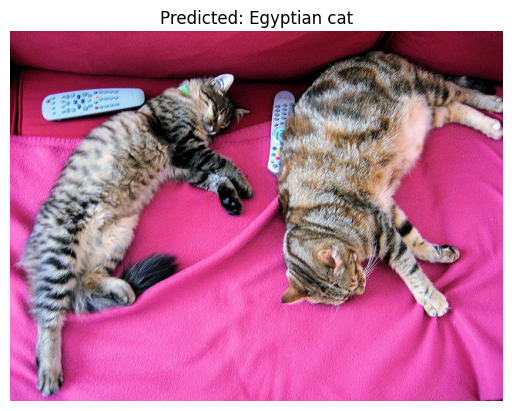

In [ ]:
# 이미지 확인
import matplotlib.pyplot as plt

plt.imshow(image)
plt.axis('off')
plt.title(f'Predicted: {model.config.id2label[predicted_class_idx]}')
plt.show()

In [ ]:
## (활용) Model에 들어가는 Input / Output 파악하기
## Model 에 들어가는 변수 : inputs
## Model 에서 나오는 변수 : outputs -> outputs.logits

import torch

test_logits = torch.tensor([[0.1, 0.7, 0.2], [0.8, 0.1, 0.1]])

labels = ['개', '고양이', '거북이']

pred = test_logits.argmax(-1)
print(pred)

---
# 2. 감성 분석 (Sentiment Analysis)

**모델:** `hun3359/klue-bert-base-sentiment`  
**모델 카드:** https://huggingface.co/hun3359/klue-bert-base-sentiment  
**파라미터:** 110M

## 모델 설명

KLUE-BERT 기반의 한국어 감성 분석 모델로, 한국어 텍스트를 5단계로 분류합니다.  
- 텍스트를 입력하면 **매우부정 / 부정 / 중립 / 긍정 / 매우긍정** 중 하나로 분류
- 상품 리뷰, 영화 리뷰, 소셜 미디어 감성 분석에 활용 가능
- **한국어 텍스트 전용**

In [4]:
# 모델 카드 예제 코드 (https://huggingface.co/hun3359/klue-bert-base-sentiment)
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_name = 'hun3359/klue-bert-base-sentiment'

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

inputs = tokenizer('이 제품 정말 최고예요!', return_tensors='pt')
with torch.no_grad():
    logits = model(**inputs).logits

predicted_class_id = logits.argmax().item()
print('결과:', model.config.id2label[predicted_class_id])

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: hun3359/klue-bert-base-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


결과: 만족스러운


In [10]:
inputs = tokenizer('승헌님이 웃을땐', return_tensors='pt')
with torch.no_grad():
    logits = model(**inputs).logits

predicted_class_id = logits.argmax().item()
print('결과:', model.config.id2label[predicted_class_id])

결과: 눈물이 나는


In [8]:
# pipeline으로 더 간단하게 사용하기
from transformers import pipeline

classifier = pipeline('sentiment-analysis', model='hun3359/klue-bert-base-sentiment')

texts = [
    '이 제품 정말 최고예요! 강력 추천합니다.',
    '배송이 너무 늦고 품질도 별로네요.',
    '그냥 그저 그래요. 평범합니다.',
]

results = classifier(texts)
for text, result in zip(texts, results, strict=False):
    print(f'[{result["label"]} {result["score"]:.2%}] {text}')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: hun3359/klue-bert-base-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[만족스러운 36.10%] 이 제품 정말 최고예요! 강력 추천합니다.
[실망한 11.53%] 배송이 너무 늦고 품질도 별로네요.
[마비된 12.01%] 그냥 그저 그래요. 평범합니다.


---
# 3. 텍스트 생성 - 한국어 대화 (Text Generation)

**모델:** `kakaocorp/kanana-nano-2.1b-instruct`  
**모델 카드:** https://huggingface.co/kakaocorp/kanana-nano-2.1b-instruct  
**파라미터:** 2.1B  
**만든 곳:** 카카오 (Kakao Corp.)

## 모델 설명

Kanana Nano는 카카오가 만든 한국어/영어 이중언어 instruction-tuned 모델입니다.  
- **Instruct 모델**: 질문을 입력하면 바로 답변 생성 (대화 바로 가능)
- 한국어 성능이 우수하며, 2.1B 파라미터로 소형 기기에서도 실행 가능
- `trust_remote_code` 없이 표준 transformers로 바로 사용 가능
- CPU에서도 실행 가능 (단, 응답 생성에 수십 초 소요)

In [11]:
# 모델 카드 예제 코드 (https://huggingface.co/kakaocorp/kanana-nano-2.1b-instruct)
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = 'kakaocorp/kanana-nano-2.1b-instruct'

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float32,  # CPU는 float32 사용
)

# 질문 바로 입력 → 답변 생성
messages = [
    {'role': 'system', 'content': 'You are a helpful AI assistant developed by Kakao.'},
    {'role': 'user', 'content': '한국의 수도는 어디야? 간단히 알려줘.'},
]

model_inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors='pt',
    return_dict=True,
)

with torch.no_grad():
    output = model.generate(
        **model_inputs,
        max_new_tokens=100,
        do_sample=False,
    )

# 입력 부분 제외하고 생성된 답변만 출력
response = tokenizer.decode(
    output[0][model_inputs['input_ids'].shape[-1] :], skip_special_tokens=True
)
print('[질문] 한국의 수도는 어디야? 간단히 알려줘.')
print(f'[답변] {response}')

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.17G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


[질문] 한국의 수도는 어디야? 간단히 알려줘.
[답변] 한국의 수도는 서울입니다.


In [12]:
# 다른 질문으로 직접 해보기
questions = [
    '인공지능이 뭔지 한 문장으로 설명해줘.',
    '파이썬과 자바의 차이점을 간단히 알려줘.',
]

for question in questions:
    messages = [
        {
            'role': 'system',
            'content': 'You are a helpful AI assistant developed by Kakao.',
        },
        {'role': 'user', 'content': question},
    ]
    model_inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors='pt',
        return_dict=True,
    )
    with torch.no_grad():
        output = model.generate(
            **model_inputs,
            max_new_tokens=100,
            do_sample=False,
        )
    response = tokenizer.decode(
        output[0][model_inputs['input_ids'].shape[-1] :], skip_special_tokens=True
    )
    print(f'[질문] {question}')
    print(f'[답변] {response}')
    print()

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


[질문] 인공지능이 뭔지 한 문장으로 설명해줘.
[답변] 인공지능은 컴퓨터 시스템이 인간의 학습, 추론, 문제 해결 능력을 모방하여 자동으로 지능적인 결정을 내리고 작업을 수행할 수 있도록 하는 기술입니다.TT

[질문] 파이썬과 자바의 차이점을 간단히 알려줘.
[답변] 물론입니다! 파이썬과 자바는 둘 다 널리 사용되는 프로그래밍 언어이지만, 몇 가지 중요한 차이점이 있습니다. 아래에 그 주요 차이점을 간단히 정리해 드리겠습니다.

### 1. **언어 철학 및 사용 목적**

- **파이썬 (Python)**:
  - **간결하고 읽기 쉬운 문법**: 가독성이 높고, 코드



In [14]:
# 원본 (모델 카드 샘플 코드) - 아래 3가지 이유로 로컬 CPU 환경에서는 오류 발생
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = 'kakaocorp/kanana-nano-2.1b-instruct'

######## 다른점
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16,  # ❌ 오류 원인 1: bfloat16은 GPU 전용 자료형. CPU에서는 지원 안 되거나 매우 느림 → float32로 변경 필요
    trust_remote_code=True,  # ⚠️ 오류 원인 2: 이 모델은 trust_remote_code가 필요 없음. 오히려 불필요한 경고 발생
).to(
    'cuda'
)  # ❌ 오류 원인 3: GPU(CUDA)가 없는 환경에서 .to("cuda") 호출 시 RuntimeError 발생 → .to("cpu") 또는 제거 필요
tokenizer = AutoTokenizer.from_pretrained(model_name)

prompt = 'Convert these dates to YYYY/MM/DD format:\n12/31/2021\n02-01-22'
messages = [
    {'role': 'system', 'content': 'You are a helpful AI assistant developed by Kakao.'},
    {'role': 'user', 'content': prompt},
]

input_ids = tokenizer.apply_chat_template(
    messages, tokenize=True, add_generation_prompt=True, return_tensors='pt'
).to('cuda')  # ❌ 오류 원인 3 (동일): 입력 텐서도 cuda로 보내려 해서 오류 발생

_ = model.eval()
with torch.no_grad():
    output = model.generate(
        input_ids,
        max_new_tokens=72,
        do_sample=False,
    )

print(tokenizer.decode(output[0], skip_special_tokens=True))

# Output:
# Sure! Here are the given dates converted to the `YYYY/MM/DD` format:

# 1. **12/31/2021**
#    - **YYYY/MM/DD:** 2021/12/31

# 2. **02-01-22**
#    - **YYYY/MM/DD:** 2022/02/01

# So, the converted dates are ...

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

AttributeError: 